<a href="https://colab.research.google.com/github/tanujk21/tanujk21-ML-Learning/blob/main/Feature_scaling_02_normilization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
from google.colab import files
uploaded=files.upload()

Saving wine_data.csv to wine_data (1).csv


In [37]:
df=pd.read_csv('wine_data.csv')  #read and convert into datagframe
df=df[['class_label','alcohol','malic_acid']]
df

,class_label,alcohol,malic_acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='alcohol', ylabel='Density'>

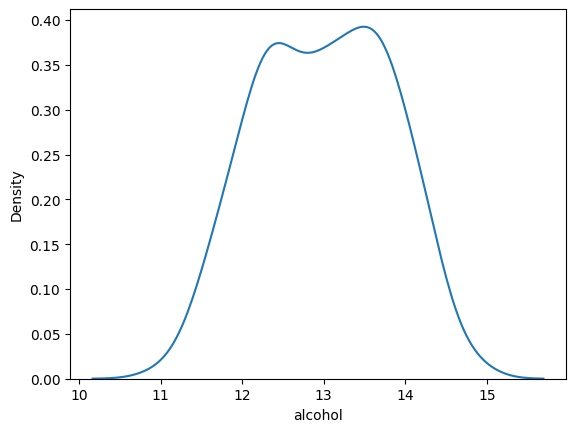

In [38]:
sns.kdeplot(df['alcohol'])

<Axes: xlabel='malic_acid', ylabel='Density'>

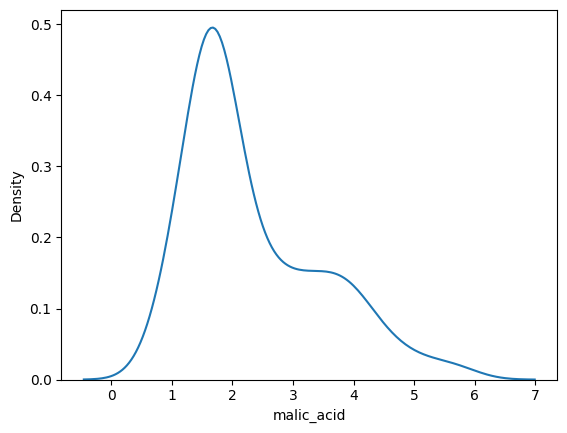

In [39]:
sns.kdeplot(df['malic_acid'])

<Axes: xlabel='alcohol', ylabel='malic_acid'>

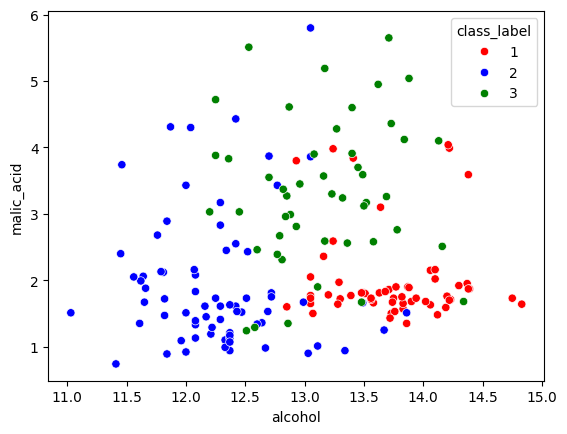

In [40]:
color_dict={1:'red',2:'blue',3:'green'}
sns.scatterplot(x='alcohol',y='malic_acid',data=df,hue='class_label',palette=color_dict)

In [41]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop('class_label',axis=1),df['class_label'],test_size=0.3,random_state=0)
# in this x have while dataframe except class label and y has class label (result)
x_train.shape,x_test.shape

((124, 2), (54, 2))

In [42]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
#fitting the scaler to the test set, learn parameters
scaler.fit(x_train)
#transforming the train data
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [43]:
# during transfrom data converted to numpy array to convert it into dataframe we do likt that
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [44]:
np.round(x_train.describe(),1)

,alcohol,malic_acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [45]:
np.round(x_train_scaled.describe(),1)

,alcohol,malic_acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


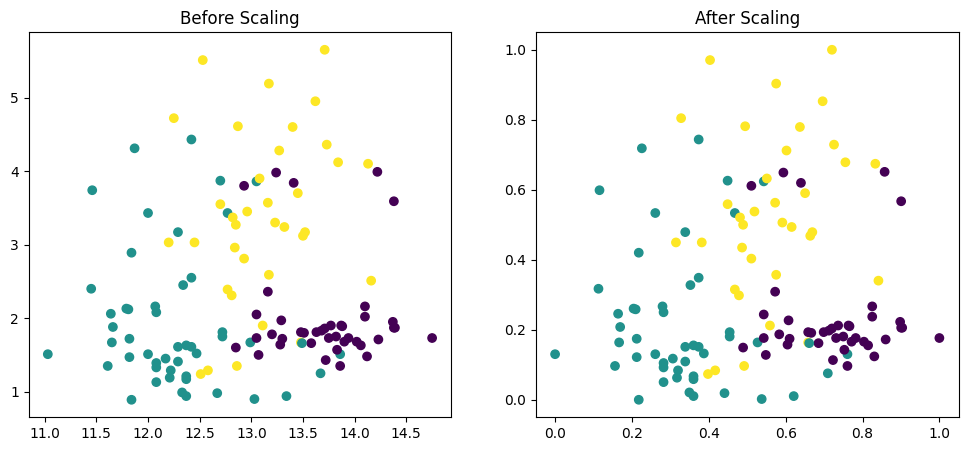

In [51]:
fig ,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_train['alcohol'],x_train['malic_acid'],c=y_train)
ax1.set_title('Before Scaling')
ax2.scatter(x_train_scaled['alcohol'],x_train_scaled['malic_acid'],c=y_train)
ax2.set_title('After Scaling')
plt.show()
#here c is color and y_train contain class labels

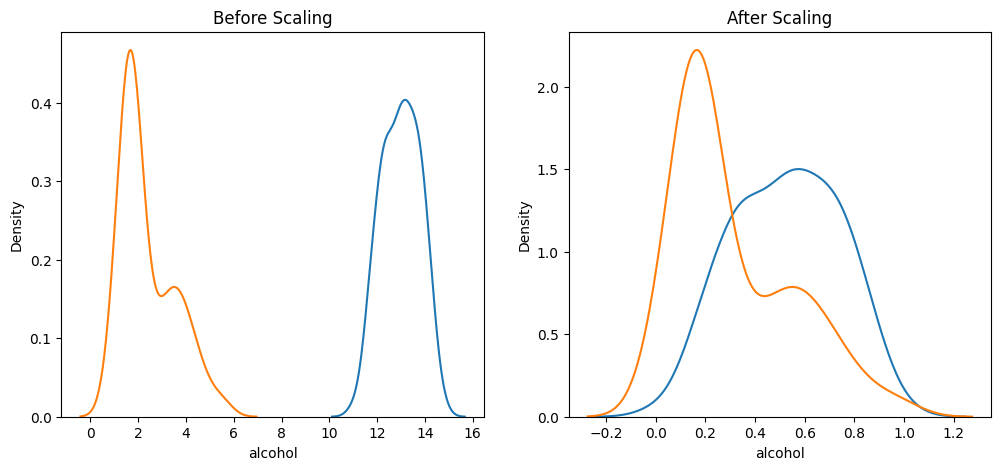

In [62]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
sns.kdeplot(x_train['alcohol'],ax=ax1)
sns.kdeplot(x_train['malic_acid'],ax=ax1)
ax1.set_title('Before Scaling')
sns.kdeplot(x_train_scaled['alcohol'],ax=ax2)
sns.kdeplot(x_train_scaled['malic_acid'],ax=ax2)
ax2.set_title('After Scaling')
plt.show()